# Exercise 1 — Logistic Regression

## Part A: Understanding Logistic Regression

Imagine we want to predict whether a student will pass an exam.

For each student, we know:

* the number of study hours
* whether the student passed or failed

Our goal is to predict: `pass (1) or fail (0)`

Unlike linear regression, logistic regression predicts a probability between 0 and 1.

### Logistic Regression Model

The model is:

`z = weight × x + bias`

Then we apply the sigmoid function:

`p = 1 / (1 + e^(-z))`

Where:

* x = input feature (study hours)
* weight = importance of the feature
* bias = shifts the curve
* p = probability of passing

### Decision Rule

After computing the probability:

`if p > 0.5 → predict PASS

else → predict FAIL`

Your Task

Change the values of: `weight` and `bias` as in previous exercises.

until the sigmoid curve separates the two classes as well as possible.

Try to understand:

* what the weight changes
* what the bias changes
* where the decision boundary appears

### Sample Student Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# x = study hours
x = np.array([0,1,2,3,4,5,6,7,8,9])

# y = fail(0) or pass(1)
y = np.array([0,0,0,0,0,1,1,1,1,1])

In [60]:
weight = 2.5
bias = -11

### Logistic Regression Predictions

In [34]:
# Linear part
z = weight * x + bias

# Sigmoid
p = 1 / (1 + np.exp(-z))

# Predicted classes
y_pred = (p > 0.5).astype(int)

### Plot the model

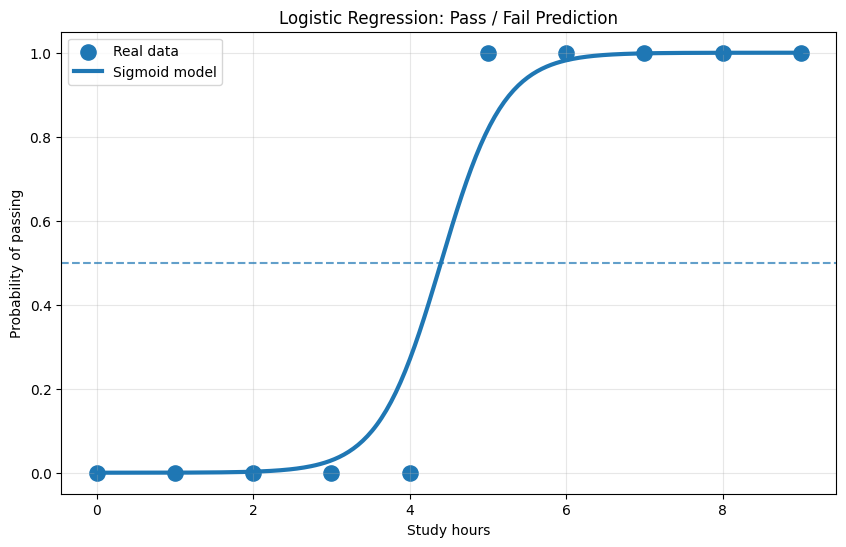

In [61]:
plt.figure(figsize=(10,6))

# Real data
plt.scatter(x, y, s=120, label="Real data")

# Smooth sigmoid curve
x_curve = np.linspace(0, 9, 300)
z_curve = weight * x_curve + bias
p_curve = 1 / (1 + np.exp(-z_curve))

plt.plot(x_curve, p_curve, linewidth=3, label="Sigmoid model")

# Decision threshold
plt.axhline(0.5, linestyle="--", alpha=0.7)

plt.xlabel("Study hours")
plt.ylabel("Probability of passing")
plt.title("Logistic Regression: Pass / Fail Prediction")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

### Questions

1. What does the weight control?
2. What does the bias control?
3. What happens when the sigmoid becomes steeper?
4. Where is the decision boundary?
5. Which students are difficult to classify?
6. Why is logistic regression better than linear regression here?

### Answers
1. The weight will change the steepness of the sigmoid function\
   The bigger value of weight, the steeper the function is.
2. The bias will shift the sigmoid function left or right.
3. When the sigmoid becomes steeper, the transition between predicting an outcome of 0 and an outcome of 1 becomes much more aburpt.
4. The decision boundary appear when z = 0 and we find out that x = - bias / weight, and especially in binary classification the decision boundary will be at a tipping point where the machine is 50% sure about the decision.
5. The ones which located near the decision boundary is hard to classify.
6. Logistic regression is better at classification since it valid probabilities, all prediction is between 0 and 1, while linear regression sketch a infinite line.

## Part B — Use a Real Dataset

Now repeat the same process using a real dataset.

Choose:

- one numerical column as `x`
- one binary column as `y`

Below are beginner-friendly datasets you can use.

| Dataset | Link | Example `x` | Example `y` | Task |
|---|---|---|---|---|
| Titanic | [Open dataset](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv) | `Age`, `Fare` | `Survived` | Predict survival |
| Breast Cancer Wisconsin | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) | `mean radius`, `mean texture` | `target` | Benign vs malignant |
| Heart Disease | [Open dataset](https://archive.ics.uci.edu/dataset/45/heart+disease) | `cholesterol`, `age` | `disease` | Predict heart disease |
| Palmer Penguins | [Open dataset](https://github.com/allisonhorst/palmerpenguins) | `bill_length_mm`, `body_mass_g` | species converted to binary | Classify penguin species |
| Student Performance | [Open dataset](https://archive.ics.uci.edu/dataset/320/student+performance) | `studytime`, `absences` | pass/fail from final grade | Predict pass/fail |
| SMS Spam | [Open dataset](https://archive.ics.uci.edu/dataset/228/sms+spam+collection) | message length, number of keywords | spam / ham | Spam detection |

### Suggested choice 

Use the **Titanic dataset** first:

In [118]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Your Real-Data Task

1. Load the dataset.
2. Display the first rows with df.head().
3. Choose one feature x.
4. Choose one binary target y.
5. Plot the data.
6. Try different values of weight and bias.
7. Observe how the sigmoid changes.
8. Compare your intuition with Python’s logistic regression model.

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

df["Age"] = df["Age"].fillna(df["Age"].median())

X = df[["Age"]]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Weight for Age (w): {model.coef_[0][0]:.4f}")
print(f"Bias (b): {model.intercept_[0]:.4f}\n")

Accuracy: 0.5866
Weight for Age (w): -0.1006
Bias (b): -0.5061



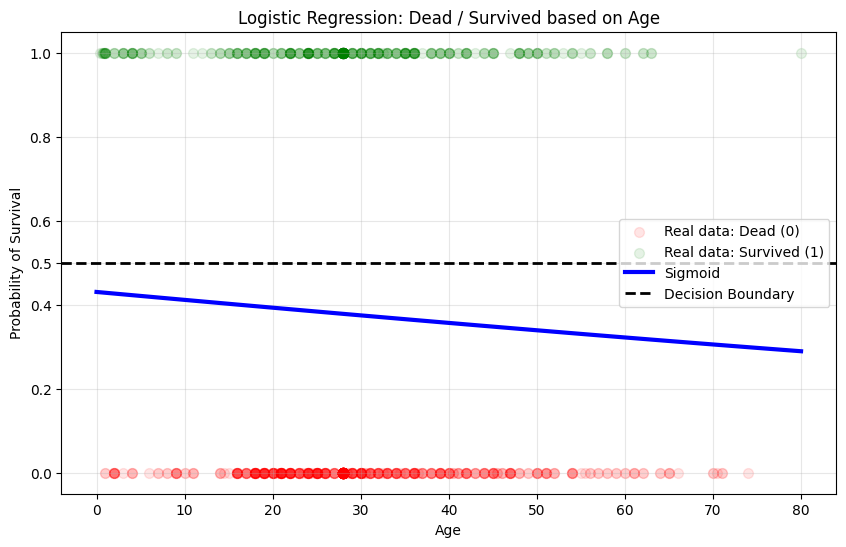

In [8]:
plt.figure(figsize=(10, 6))

plot_x = df["Age"].values
plot_y = df["Survived"].values

plt.scatter(plot_x[plot_y == 0], plot_y[plot_y == 0], color='red', alpha=0.1, s=50, label='Real data: Dead (0)')
plt.scatter(plot_x[plot_y == 1], plot_y[plot_y == 1], color='green', alpha=0.1, s=50, label='Real data: Survived (1)')

x_line = np.linspace(0, 80, 100).reshape(-1, 1)

x_line_df = pd.DataFrame(x_line, columns=["Age"])
x_line_scaled = scaler.transform(x_line_df) 

y_prob = model.predict_proba(x_line_scaled)[:, 1]

plt.plot(x_line, y_prob, color='blue', linewidth=3, label='Sigmoid')

plt.axhline(y=0.5, color='black', linestyle='--', linewidth=2, label='Decision Boundary')

plt.title("Logistic Regression: Dead / Survived based on Age")
plt.xlabel("Age")
plt.ylabel("Probability of Survival")
plt.yticks([0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]) 
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)
plt.show()